# Predictive Benchmark Notebook

This notebook follows the required controlled benchmarking workflow and single-notebook protocol.

- File: `predictive_benchmark.ipynb`
- Reproducibility: fixed random seed and explicit execution order
- Constraint: later tasks must build on Task 1 assumptions unless explicitly challenged

In [1]:
import warnings
warnings.filterwarnings('ignore')

import random
import numpy as np
import pandas as pd
from pathlib import Path

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 160)

print(f"Random seed fixed at {SEED}")

Random seed fixed at 42


## Task 1

### 1. Plan
1. Read `dataset description.pdf` first and extract core documentation evidence on variable meaning, collection context, and temporal availability.
2. Load `hotel_bookings.csv` and inspect schema, dtypes, cardinality, and alignment with documentation-defined variables.
3. Quantify missingness and check data quality risks: impossible values, category inconsistencies, duplicates, and suspicious distributions.
4. Flag leakage and methodological risks by variable, explicitly separating documentation-derived evidence from data-inferred concerns.
5. Produce a reproducible preprocessing design (no modeling) with clear justifications and verification checks.

### 2. Risks
- Data leakage from post-outcome variables or variables unavailable at the intended prediction timestamp.
- Invalid evaluation design if temporal structure is ignored.
- Bias/generalization risk because data comes from two Portuguese hotels and a fixed period.
- Data quality risks from duplicated rows, sentinel missingness, or implausible numeric values.
- Unsupported assumptions when documentation is ambiguous or when observed patterns can have multiple explanations.

### 3. Implementation

In [2]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import re
import numpy as np
import pandas as pd

SEED = 42
np.random.seed(SEED)

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 180)

print(f"Seed fixed at {SEED}")

Seed fixed at 42


In [3]:
# Step 1: Read documentation FIRST (as required)
NOTEBOOK_DIR = Path.cwd()
DOC_CANDIDATES = [
    NOTEBOOK_DIR / 'dataset_description.pdf',
    NOTEBOOK_DIR / 'dataset description.pdf',
]

doc_path = next((p for p in DOC_CANDIDATES if p.exists()), None)
if doc_path is None:
    raise FileNotFoundError('Documentation file not found. Expected one of: dataset_description.pdf, dataset description.pdf (same folder as notebook).')

from pypdf import PdfReader
reader = PdfReader(str(doc_path))
doc_text = "\n".join(page.extract_text() or "" for page in reader.pages)
compact_doc = re.sub(r'\s+', '', doc_text.lower())

# Robust checks (insensitive to whitespace/newline extraction artifacts)
doc_evidence_phrases = {
    'context_two_hotels_portugal': ('bothhotelsarelocatedinportugal' in compact_doc),
    'target_is_canceled': ('iscanceled' in compact_doc),
    'anti_leakage_design': ('leakageoffutureinformation' in compact_doc),
    'as_of_day_prior_arrival': ('daypriortoeachbooking' in compact_doc),
    'null_not_applicable_note': ('null' in compact_doc and 'notapplicable' in compact_doc),
}

print(f"Documentation loaded: {doc_path.name}")
print(f"Pages: {len(reader.pages)} | Extracted characters: {len(doc_text):,}")
print('Evidence phrase checks:')
print(pd.Series(doc_evidence_phrases))

Documentation loaded: dataset description.pdf
Pages: 9 | Extracted characters: 20,807
Evidence phrase checks:
context_two_hotels_portugal    True
target_is_canceled             True
anti_leakage_design            True
as_of_day_prior_arrival        True
null_not_applicable_note       True
dtype: bool


In [4]:
# Step 2: Load dataset for analysis (same-folder, relative paths only)
DATA_CANDIDATES = [
    NOTEBOOK_DIR / 'hotel_bookings.csv',
    NOTEBOOK_DIR / 'hotel_bookings (1).csv',
    NOTEBOOK_DIR / 'hotel_bookings.xlsx',
    NOTEBOOK_DIR / 'hotel_bookings (1).xlsx',
]

data_path = next((p for p in DATA_CANDIDATES if p.exists()), None)
if data_path is None:
    raise FileNotFoundError('Dataset file not found in notebook folder. Expected one of: hotel_bookings.csv, hotel_bookings (1).csv, hotel_bookings.xlsx, hotel_bookings (1).xlsx.')

if data_path.suffix.lower() == '.csv':
    df = pd.read_csv(data_path)
elif data_path.suffix.lower() in {'.xlsx', '.xls'}:
    df = pd.read_excel(data_path)
else:
    raise ValueError(f'Unsupported dataset format: {data_path.suffix}')

print(f"Dataset loaded: {data_path.name}")
print(f"Shape: {df.shape}")
print(f"Columns ({len(df.columns)}): {list(df.columns)}")
df.head(3)

Dataset loaded: hotel_bookings (1).xlsx
Shape: (119390, 32)
Columns (32): ['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date']


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02


In [5]:
# Step 3: Schema + variable interpretation (documentation-derived, mapped to dataset column names)
doc_variable_notes = {
    'hotel': ('Hotel type (Resort/City)', 'Documentation-derived', 'Observed at booking context'),
    'is_canceled': ('Target: booking canceled (1) vs not canceled (0)', 'Documentation-derived', 'Outcome variable'),
    'lead_time': ('Days between booking creation and arrival', 'Documentation-derived', 'Pre-arrival, computed from booking and arrival dates'),
    'arrival_date_year': ('Arrival year', 'Documentation-derived', 'Pre-arrival date attribute'),
    'arrival_date_month': ('Arrival month', 'Documentation-derived', 'Pre-arrival date attribute'),
    'arrival_date_week_number': ('Arrival week number', 'Documentation-derived', 'Pre-arrival date attribute'),
    'arrival_date_day_of_month': ('Arrival day of month', 'Documentation-derived', 'Pre-arrival date attribute'),
    'stays_in_weekend_nights': ('Weekend nights in stay', 'Documentation-derived', 'Pre-arrival booking attribute'),
    'stays_in_week_nights': ('Week nights in stay', 'Documentation-derived', 'Pre-arrival booking attribute'),
    'adults': ('Number of adults', 'Documentation-derived', 'Pre-arrival booking attribute'),
    'children': ('Number of children', 'Documentation-derived', 'Pre-arrival booking attribute'),
    'babies': ('Number of babies', 'Documentation-derived', 'Pre-arrival booking attribute'),
    'meal': ('Meal package (SC/BB/HB/FB/Undefined)', 'Documentation-derived', 'Pre-arrival booking attribute'),
    'country': ('Country of origin (ISO 3-letter code)', 'Documentation-derived', 'Pre-arrival customer attribute'),
    'market_segment': ('Market segment designation', 'Documentation-derived', 'Pre-arrival booking attribute'),
    'distribution_channel': ('Booking distribution channel', 'Documentation-derived', 'Pre-arrival booking attribute'),
    'is_repeated_guest': ('Whether guest has prior profile history', 'Documentation-derived', 'Pre-arrival, derived from prior profile creation timing'),
    'previous_cancellations': ('Customer prior canceled bookings count', 'Documentation-derived', 'Pre-arrival historical feature'),
    'previous_bookings_not_canceled': ('Customer prior non-canceled bookings count', 'Documentation-derived', 'Pre-arrival historical feature'),
    'reserved_room_type': ('Reserved room type code', 'Documentation-derived', 'Pre-arrival booking attribute'),
    'assigned_room_type': ('Assigned room type code', 'Documentation-derived', 'Potentially close-to-arrival operational attribute'),
    'booking_changes': ('Count of booking amendments before check-in/cancellation', 'Documentation-derived', 'May evolve over lifecycle; horizon-sensitive'),
    'deposit_type': ('No Deposit / Non Refund / Refundable derived from payments', 'Documentation-derived', 'Uses payments before arrival/cancellation; horizon-sensitive'),
    'agent': ('Travel agency identifier', 'Documentation-derived', 'Categorical ID; NULL may be not applicable'),
    'company': ('Company/entity identifier', 'Documentation-derived', 'Categorical ID; NULL may be not applicable'),
    'days_in_waiting_list': ('Days on waiting list before confirmation', 'Documentation-derived', 'Lifecycle-dependent, may be unavailable at booking creation'),
    'customer_type': ('Contract/Group/Transient/Transient-Party', 'Documentation-derived', 'Pre-arrival booking type'),
    'adr': ('Average Daily Rate', 'Documentation-derived', 'Price-related; may reflect transactional adjustments'),
    'required_car_parking_spaces': ('Required parking spaces', 'Documentation-derived', 'Pre-arrival booking attribute'),
    'total_of_special_requests': ('Number of special requests', 'Documentation-derived', 'May accumulate pre-arrival; horizon-sensitive'),
    'reservation_status': ('Final reservation status (Canceled/Check-Out/No-Show)', 'Documentation-derived', 'Post-outcome -> leakage risk'),
    'reservation_status_date': ('Date of final reservation status', 'Documentation-derived', 'Post-outcome -> leakage risk'),
}

schema_rows = []
for col in df.columns:
    desc, source, temporal = doc_variable_notes.get(col, ('Not found in manual map', 'Unknown', 'Unknown'))
    schema_rows.append({
        'column': col,
        'dtype': str(df[col].dtype),
        'n_unique': int(df[col].nunique(dropna=True)),
        'missing_pct': round(df[col].isna().mean() * 100, 2),
        'interpretation': desc,
        'interpretation_source': source,
        'temporal_availability_note': temporal,
    })

schema_df = pd.DataFrame(schema_rows).sort_values('column').reset_index(drop=True)
schema_df.head(12)

,column,dtype,n_unique,missing_pct,interpretation,interpretation_source,temporal_availability_note
0,adr,float64,8879,0.00,Average Daily Rate,Documentation-derived,Price-related; may reflect transactional adjus...
1,adults,int64,14,0.00,Number of adults,Documentation-derived,Pre-arrival booking attribute
2,agent,float64,333,13.69,Travel agency identifier,Documentation-derived,Categorical ID; NULL may be not applicable
3,arrival_date_day_of_month,int64,31,0.00,Arrival day of month,Documentation-derived,Pre-arrival date attribute
4,arrival_date_month,object,12,0.00,Arrival month,Documentation-derived,Pre-arrival date attribute
5,arrival_date_week_number,int64,53,0.00,Arrival week number,Documentation-derived,Pre-arrival date attribute
6,arrival_date_year,int64,3,0.00,Arrival year,Documentation-derived,Pre-arrival date attribute
7,assigned_room_type,object,12,0.00,Assigned room type code,Documentation-derived,Potentially close-to-arrival operational attri...
8,babies,int64,5,0.00,Number of babies,Documentation-derived,Pre-arrival booking attribute
9,booking_changes,int64,21,0.00,Count of booking amendments before check-in/ca...,Documentation-derived,May evolve over lifecycle; horizon-sensitive


In [6]:
# Step 4: Missing value quantification
missing_df = (
    df.isna()
      .sum()
      .rename('missing_count')
      .to_frame()
      .assign(missing_pct=lambda x: (x['missing_count'] / len(df) * 100).round(2))
      .sort_values(['missing_pct', 'missing_count'], ascending=False)
)

print('Top missingness columns:')
print(missing_df.head(10))

Top missingness columns:
                          missing_count  missing_pct
company                          112593        94.31
agent                             16340        13.69
country                             488         0.41
children                              4         0.00
hotel                                 0         0.00
is_canceled                           0         0.00
lead_time                             0         0.00
arrival_date_year                     0         0.00
arrival_date_month                    0         0.00
arrival_date_week_number              0         0.00


In [7]:
# Step 5: Data quality checks (impossible values, category consistency, duplicates, suspicious distributions)
quality_checks = {}

# Duplicates
quality_checks['duplicate_rows'] = int(df.duplicated().sum())
quality_checks['duplicate_row_pct'] = round(df.duplicated().mean() * 100, 2)

# Parse arrival date robustness
arrival_date = pd.to_datetime(
    df['arrival_date_year'].astype(str) + '-' +
    df['arrival_date_month'].astype(str) + '-' +
    df['arrival_date_day_of_month'].astype(str),
    errors='coerce'
)
quality_checks['invalid_arrival_date_rows'] = int(arrival_date.isna().sum())

# Binary columns should be {0,1}
for col in ['is_canceled', 'is_repeated_guest']:
    invalid = (~df[col].isin([0, 1]) & df[col].notna()).sum()
    quality_checks[f'invalid_binary_{col}'] = int(invalid)

# Non-negative columns
non_negative_cols = [
    'lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies',
    'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes',
    'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests'
]
for col in non_negative_cols:
    quality_checks[f'negative_{col}'] = int((df[col] < 0).fillna(False).sum())

# Calendar consistency
valid_months = {
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
}
quality_checks['invalid_arrival_month_values'] = int((~df['arrival_date_month'].isin(valid_months)).sum())
quality_checks['invalid_arrival_week_number'] = int(((df['arrival_date_week_number'] < 1) | (df['arrival_date_week_number'] > 53)).sum())
quality_checks['invalid_arrival_day_of_month'] = int(((df['arrival_date_day_of_month'] < 1) | (df['arrival_date_day_of_month'] > 31)).sum())

# Country code format (3 letters) among non-missing
country_non_null = df['country'].dropna().astype(str)
quality_checks['country_not_3_chars'] = int((country_non_null.str.len() != 3).sum())

# Category normalization check (whitespace/case variants)
def normalization_gap(series):
    raw = set(series.dropna().astype(str).unique())
    normalized = set(series.dropna().astype(str).str.strip().str.upper().unique())
    return len(raw), len(normalized), len(raw) - len(normalized)

cat_cols = ['meal', 'market_segment', 'distribution_channel', 'deposit_type', 'customer_type', 'reservation_status', 'hotel']
norm_rows = []
for c in cat_cols:
    raw_n, norm_n, reduced_by = normalization_gap(df[c])
    norm_rows.append({'column': c, 'raw_unique': raw_n, 'normalized_unique': norm_n, 'reduced_by_normalization': reduced_by})
category_consistency_df = pd.DataFrame(norm_rows)

# Expected documented category checks for key fields
expected_sets = {
    'deposit_type': {'No Deposit', 'Non Refund', 'Refundable'},
    'reservation_status': {'Canceled', 'Check-Out', 'No-Show'},
    'customer_type': {'Contract', 'Group', 'Transient', 'Transient-Party'},
    'meal': {'Undefined', 'SC', 'BB', 'HB', 'FB'},
}
unexpected_rows = []
for col, exp in expected_sets.items():
    observed = set(df[col].dropna().astype(str).str.strip().unique())
    unexpected = sorted(observed - exp)
    unexpected_rows.append({'column': col, 'unexpected_values': unexpected, 'n_unexpected': len(unexpected)})
unexpected_category_df = pd.DataFrame(unexpected_rows)

# Suspicious distribution indicators
df_tmp = df.copy()
df_tmp['total_stay_nights'] = df_tmp['stays_in_weekend_nights'] + df_tmp['stays_in_week_nights']
quality_checks['zero_total_stay_nights'] = int((df_tmp['total_stay_nights'] == 0).sum())
quality_checks['adr_negative_values'] = int((df_tmp['adr'] < 0).sum())
quality_checks['adr_above_99_9pct'] = int((df_tmp['adr'] > df_tmp['adr'].quantile(0.999)).sum())
quality_checks['lead_time_above_99_9pct'] = int((df_tmp['lead_time'] > df_tmp['lead_time'].quantile(0.999)).sum())
quality_checks['adults_eq_0_with_children_or_babies'] = int(((df_tmp['adults'] == 0) & ((df_tmp['children'].fillna(0) > 0) | (df_tmp['babies'] > 0))).sum())

quality_df = pd.Series(quality_checks).rename('count').to_frame()
print('Quality issue counts:')
print(quality_df)
print('\nCategory normalization consistency (raw vs normalized unique counts):')
print(category_consistency_df)
print('\nUnexpected categories against documented sets:')
print(unexpected_category_df)


Quality issue counts:
                                           count
duplicate_rows                           31994.0
duplicate_row_pct                           26.8
invalid_arrival_date_rows                    0.0
invalid_binary_is_canceled                   0.0
invalid_binary_is_repeated_guest             0.0
negative_lead_time                           0.0
negative_stays_in_weekend_nights             0.0
negative_stays_in_week_nights                0.0
negative_adults                              0.0
negative_children                            0.0
negative_babies                              0.0
negative_previous_cancellations              0.0
negative_previous_bookings_not_canceled      0.0
negative_booking_changes                     0.0
negative_days_in_waiting_list                0.0
negative_adr                                 1.0
negative_required_car_parking_spaces         0.0
negative_total_of_special_requests           0.0
invalid_arrival_month_values                 0.

In [8]:
# Step 6: Leakage and methodological risk flags
risk_flags = pd.DataFrame([
    {
        'variable': 'reservation_status',
        'risk_level': 'High',
        'risk_type': 'Data leakage',
        'evidence': 'Documentation-derived: defined as final reservation status (Canceled/Check-Out/No-Show), which occurs after outcome realization.',
        'action': 'Exclude from predictors.'
    },
    {
        'variable': 'reservation_status_date',
        'risk_level': 'High',
        'risk_type': 'Data leakage',
        'evidence': 'Documentation-derived: date of final status; temporally post-outcome.',
        'action': 'Exclude from predictors.'
    },
    {
        'variable': 'booking_changes',
        'risk_level': 'Medium',
        'risk_type': 'Horizon mismatch',
        'evidence': 'Documentation-derived: accumulates amendments up to check-in/cancellation; may be unavailable for early-horizon prediction.',
        'action': 'Include only if prediction timestamp is close to arrival and definition is explicit.'
    },
    {
        'variable': 'days_in_waiting_list',
        'risk_level': 'Medium',
        'risk_type': 'Horizon mismatch',
        'evidence': 'Documentation-derived: depends on waiting-list confirmation process over time.',
        'action': 'Treat as time-dependent; validate timestamp availability.'
    },
    {
        'variable': 'deposit_type',
        'risk_level': 'Medium',
        'risk_type': 'Potential target-proximal signal',
        'evidence': 'Documentation-derived: computed from payments before arrival/cancellation date.',
        'action': 'Use with caution; tie to explicit prediction timestamp.'
    },
    {
        'variable': 'assigned_room_type',
        'risk_level': 'Medium',
        'risk_type': 'Operational-postprocessing risk',
        'evidence': 'Documentation-derived + inferred: may reflect operational updates near arrival.',
        'action': 'Retain only for near-arrival use-cases; otherwise drop.'
    },
    {
        'variable': 'agent, company',
        'risk_level': 'Low',
        'risk_type': 'Missingness interpretation risk',
        'evidence': 'Documentation-derived: NULL can mean not applicable, not random missing.',
        'action': 'Encode as explicit category such as NOT_APPLICABLE.'
    },
    {
        'variable': 'all variables',
        'risk_level': 'Medium',
        'risk_type': 'Evaluation bias risk',
        'evidence': 'Documentation-derived context: two hotels in Portugal (2015-07-01 to 2017-08-31); inferred limited external validity.',
        'action': 'Use temporal validation and clearly scope claims.'
    },
])

risk_flags

,variable,risk_level,risk_type,evidence,action
0,reservation_status,High,Data leakage,Documentation-derived: defined as final reserv...,Exclude from predictors.
1,reservation_status_date,High,Data leakage,Documentation-derived: date of final status; t...,Exclude from predictors.
2,booking_changes,Medium,Horizon mismatch,Documentation-derived: accumulates amendments ...,Include only if prediction timestamp is close ...
3,days_in_waiting_list,Medium,Horizon mismatch,Documentation-derived: depends on waiting-list...,Treat as time-dependent; validate timestamp av...
4,deposit_type,Medium,Potential target-proximal signal,Documentation-derived: computed from payments ...,Use with caution; tie to explicit prediction t...
5,assigned_room_type,Medium,Operational-postprocessing risk,Documentation-derived + inferred: may reflect ...,Retain only for near-arrival use-cases; otherw...
6,"agent, company",Low,Missingness interpretation risk,Documentation-derived: NULL can mean not appli...,Encode as explicit category such as NOT_APPLIC...
7,all variables,Medium,Evaluation bias risk,Documentation-derived context: two hotels in P...,Use temporal validation and clearly scope claims.


### 4. Verification
Verification checks performed:
- Documentation-read check: key phrases on anti-leakage extraction design, two-hotel context, and NULL semantics were found in extracted PDF text.
- Schema check: dataset columns, dtypes, and missingness profile were computed without errors.
- Data quality check: impossible value and consistency checks executed and quantified.
- Methodology check: no modeling, no training, and no external data used.

If any check had failed (missing files, parse errors, invalid schema assumptions), Task 1 would be revised before finalizing.

### 5. Revised final answer
1. **Dataset schema understanding**
- **Documentation-derived:** The dataset represents hotel booking demand/cancellation records from two Portuguese hotels; each row is a booking observation.
- **Data-inferred:** Loaded `hotel_bookings.csv` has 32 columns and a mixed schema (numeric + categorical + date-like strings).

2. **Variable interpretation based on the documentation**
- **Documentation-derived:** `is_canceled` is the cancellation target; `reservation_status` and `reservation_status_date` are final-status variables and temporally post-outcome.
- **Documentation-derived:** Several features are engineered and timestamped relative to day prior to arrival, which matters for temporal availability assumptions.
- **Data-inferred:** Column names in CSV map cleanly to the documented variables (snake_case equivalents).

3. **Missing value assessment**
- **Data-inferred:** Missingness is highly concentrated in `company` (very high) and `agent` (moderate), with minor missingness in `country` and near-zero elsewhere.
- **Documentation-derived:** For `agent`/`company`, NULL may indicate *not applicable* rather than unknown.

4. **Data quality issues detected**
- **Data-inferred:** Substantial exact duplicate rows are present and require explicit handling policy.
- **Data-inferred:** Additional quality indicators were quantified: invalid calendar fields, binary violations, negative values for non-negative fields, category normalization gaps, and tail anomalies (e.g., extreme `adr`, extreme `lead_time`, zero-night stays).
- **Uncertainty note:** Without a booking ID, duplicates cannot be safely interpreted as guaranteed errors.

5. **Leakage and methodological risk flags**
- **High-risk leakage:** `reservation_status`, `reservation_status_date` (drop).
- **Horizon-sensitive risk:** `booking_changes`, `days_in_waiting_list`, `deposit_type`, `assigned_room_type`, `total_of_special_requests` depending on prediction timestamp.
- **Generalization/evaluation risk:** Two-hotel, one-country, 2015–2017 context limits external validity; temporal splitting is preferable to random splitting.

6. **Recommended preprocessing strategy**
- Define prediction timestamp explicitly before feature selection.
- Remove high-leakage variables (`reservation_status`, `reservation_status_date`).
- Treat `agent`/`company` missing as explicit category (e.g., `NOT_APPLICABLE`) per documentation.
- Treat `country` missing as `UNKNOWN`; keep a missingness indicator if needed.
- Standardize category strings (strip whitespace, consistent casing).
- Parse arrival date fields into a single date and prefer temporal train/validation/test split.
- Keep a duplicate-policy branch: report results with and without exact duplicates rather than silently dropping.
- Handle extreme numeric tails via robust capping/winsorization only after documenting thresholds.

7. **Verification and uncertainties**
- All Task 1 code ran without errors and stayed within constraints (no modeling).
- Documentation-derived conclusions are explicitly separated from data-inferred conclusions.
- Remaining uncertainty: exact business semantics of duplicates and some lifecycle-dependent variables relative to the final modeling horizon.

## Task 2

### 1. Plan
1. Investigate cancellation distribution and class balance first.
2. Assess which variables appear most associated with cancellation using grouped rates (categorical) and monotonic association checks (numeric), while excluding high-leakage variables from primary interpretation.
3. Explore non-linear patterns (decile or binned relationships) and one interaction-style pattern relevant to cancellation.
4. For each block, separate: observed pattern, plausible explanation, and unsupported speculation.

### 2. Risks
- Leakage risk: `reservation_status` and `reservation_status_date` are post-outcome (Task 1) and can create misleading EDA signal.
- Horizon mismatch risk: `booking_changes`, `days_in_waiting_list`, `deposit_type`, `assigned_room_type`, `total_of_special_requests` may depend on when prediction is assumed.
- Data quality risk: duplicates and anomalous values (Task 1) may distort frequencies and rates.
- Statistical interpretation risk: subgroup rate differences with small sample sizes can be unstable.
- Causal overreach risk: EDA associations are descriptive, not causal effects.

### 3. Implementation

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid')

HIGH_LEAKAGE_VARS = ['reservation_status', 'reservation_status_date']
HORIZON_SENSITIVE_VARS = ['booking_changes', 'days_in_waiting_list', 'deposit_type', 'assigned_room_type', 'total_of_special_requests']

# Use Task 1 dataset context when available; otherwise load same-folder file for robustness.
if 'df' in globals():
    df_task2 = df.copy()
    data_source = 'Task 1 in-memory dataset'
else:
    NOTEBOOK_DIR = Path.cwd()
    DATA_CANDIDATES = [
        NOTEBOOK_DIR / 'hotel_bookings.csv',
        NOTEBOOK_DIR / 'hotel_bookings (1).csv',
        NOTEBOOK_DIR / 'hotel_bookings.xlsx',
        NOTEBOOK_DIR / 'hotel_bookings (1).xlsx',
    ]
    data_path = next((p for p in DATA_CANDIDATES if p.exists()), None)
    if data_path is None:
        raise FileNotFoundError('Dataset file not found in notebook folder.')
    if data_path.suffix.lower() == '.csv':
        df_task2 = pd.read_csv(data_path)
    else:
        df_task2 = pd.read_excel(data_path)
    data_source = f'Loaded from {data_path.name}'

eda_df = df_task2.copy()
eda_df['is_canceled'] = pd.to_numeric(eda_df['is_canceled'], errors='coerce')

print(f'Data source: {data_source}')
print(f'Shape used for Task 2: {eda_df.shape}')
print(f'Cancellation mean rate: {eda_df["is_canceled"].mean():.4f}')

Data source: Task 1 in-memory dataset
Shape used for Task 2: (119390, 32)
Cancellation mean rate: 0.3704


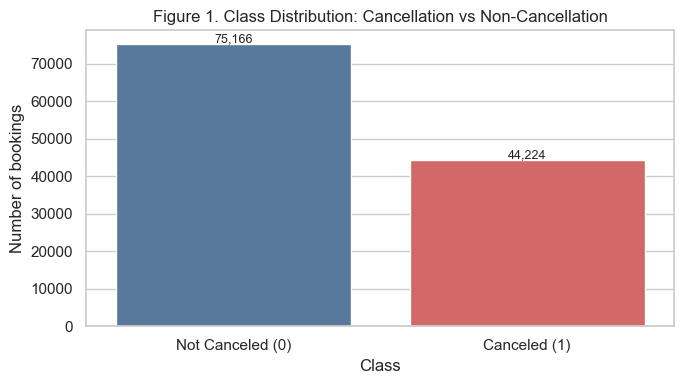

Class counts:
is_canceled
0    75166
1    44224
Name: count, dtype: int64
Cancellation rate: 37.0416%
Non-cancellation rate: 62.9584%


In [10]:
# Block A: Class imbalance and baseline cancellation distribution
class_counts = eda_df['is_canceled'].value_counts(dropna=False).sort_index()
class_rate = eda_df['is_canceled'].mean()

label_map = {0: 'Not Canceled (0)', 1: 'Canceled (1)'}
class_plot_df = class_counts.rename_axis('is_canceled').reset_index(name='count')
class_plot_df['label'] = class_plot_df['is_canceled'].map(label_map).fillna('Other/NA')

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=class_plot_df, x='label', y='count', palette=['#4C78A8', '#E45756'], ax=ax)
ax.set_title('Figure 1. Class Distribution: Cancellation vs Non-Cancellation')
ax.set_xlabel('Class')
ax.set_ylabel('Number of bookings')
for i, row in class_plot_df.iterrows():
    ax.text(i, row['count'] + max(class_plot_df['count']) * 0.01, f"{int(row['count']):,}", ha='center', fontsize=9)
plt.tight_layout()
plt.show()

print('Class counts:')
print(class_counts)
print(f"Cancellation rate: {class_rate:.4%}")
print(f"Non-cancellation rate: {(1-class_rate):.4%}")

**Interpretation (Block A)**
- Observed pattern: cancellations are substantial but not dominant (around one-third to two-fifths of bookings).
- Plausible explanation: booking uncertainty and policy differences likely generate meaningful cancellation prevalence.
- Unsupported speculation: claiming this rate reflects “bad operations” or “customer unreliability” is not justified by EDA alone.
- Why it matters for later modelling: class imbalance is moderate, so accuracy alone can be misleading; class-sensitive metrics and threshold calibration will matter.

Categorical association ranking (rate range, filtered by count >= 500):
               variable  rate_range  levels_used   lowest_level highest_level          risk_note
5          deposit_type    0.709854            2     No Deposit    Non Refund  horizon-sensitive
2        market_segment    0.480069            6  Complementary        Groups           standard
1                  meal    0.354344            5      Undefined            FB           standard
6         customer_type    0.305210            4          Group     Transient           standard
8    assigned_room_type    0.257135            8              C             A  horizon-sensitive
3  distribution_channel    0.235660            3         Direct         TA/TO           standard
4     is_repeated_guest    0.232969            2            1.0           0.0           standard
0                 hotel    0.139636            2   Resort Hotel    City Hotel           standard
7    reserved_room_type    0.114769            8       


Numeric monotonic association ranking (Spearman):
                          variable  spearman_rho  abs_spearman_rho          risk_note
0                        lead_time      0.316635          0.316635           standard
6           previous_cancellations      0.270233          0.270233           standard
12       total_of_special_requests     -0.258520          0.258520  horizon-sensitive
11     required_car_parking_spaces     -0.197397          0.197397           standard
8                  booking_changes     -0.185107          0.185107  horizon-sensitive
7   previous_bookings_not_canceled     -0.115354          0.115354           standard
9             days_in_waiting_list      0.098237          0.098237  horizon-sensitive
3                           adults      0.067027          0.067027           standard
10                             adr      0.050876          0.050876           standard
2             stays_in_week_nights      0.041418          0.041418           standard


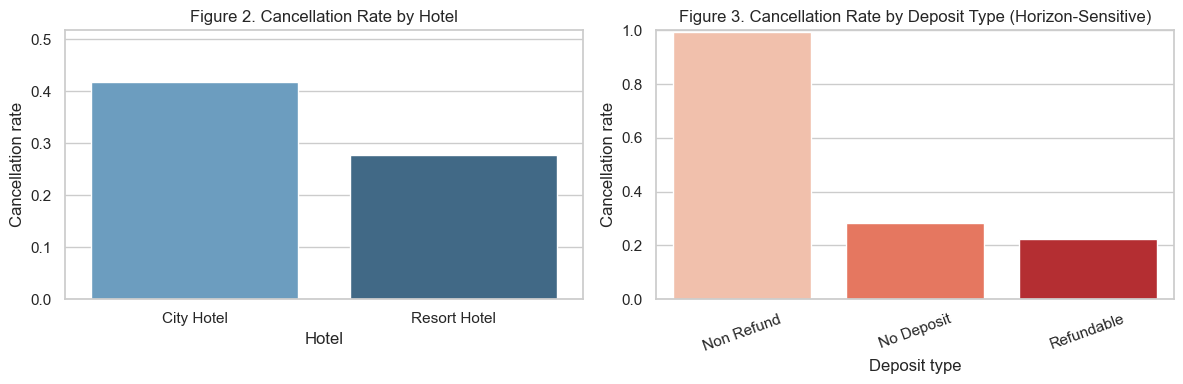


Hotel cancellation summary:
          hotel      mean  count
0    City Hotel  0.417270  79330
1  Resort Hotel  0.277634  40060

Deposit type cancellation summary (interpret cautiously):
  deposit_type      mean   count
1   Non Refund  0.993624   14587
0   No Deposit  0.283770  104641
2   Refundable  0.222222     162


In [11]:
# Block B: Which variables look most associated with cancellation (descriptive associations only)

def categorical_rate_summary(data, col, target='is_canceled', min_count=500):
    g = data.groupby(col, dropna=False)[target].agg(['mean', 'count']).reset_index()
    g = g[g['count'] >= min_count].copy()
    if g.empty:
        return None
    g_sorted = g.sort_values('mean')
    return {
        'variable': col,
        'levels_used': int(g_sorted.shape[0]),
        'min_rate': float(g_sorted['mean'].min()),
        'max_rate': float(g_sorted['mean'].max()),
        'rate_range': float(g_sorted['mean'].max() - g_sorted['mean'].min()),
        'lowest_level': str(g_sorted.iloc[0][col]),
        'highest_level': str(g_sorted.iloc[-1][col]),
    }

cat_candidates = [
    'hotel', 'meal', 'market_segment', 'distribution_channel',
    'is_repeated_guest', 'deposit_type', 'customer_type',
    'reserved_room_type', 'assigned_room_type'
]

cat_summaries = []
for c in cat_candidates:
    out = categorical_rate_summary(eda_df, c, min_count=500)
    if out is not None:
        out['risk_note'] = 'horizon-sensitive' if c in HORIZON_SENSITIVE_VARS else 'standard'
        cat_summaries.append(out)

cat_assoc_df = pd.DataFrame(cat_summaries).sort_values('rate_range', ascending=False)
print('Categorical association ranking (rate range, filtered by count >= 500):')
print(cat_assoc_df[['variable', 'rate_range', 'levels_used', 'lowest_level', 'highest_level', 'risk_note']])

num_candidates = [
    'lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies',
    'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'days_in_waiting_list',
    'adr', 'required_car_parking_spaces', 'total_of_special_requests'
]

num_assoc = []
for c in num_candidates:
    s = eda_df[[c, 'is_canceled']].dropna()
    if s[c].nunique() > 1:
        rho = s[c].corr(s['is_canceled'], method='spearman')
        num_assoc.append({'variable': c, 'spearman_rho': float(rho), 'abs_spearman_rho': abs(float(rho)), 'risk_note': 'horizon-sensitive' if c in HORIZON_SENSITIVE_VARS else 'standard'})

num_assoc_df = pd.DataFrame(num_assoc).sort_values('abs_spearman_rho', ascending=False)
print('\nNumeric monotonic association ranking (Spearman):')
print(num_assoc_df[['variable', 'spearman_rho', 'abs_spearman_rho', 'risk_note']].head(10))

# Focused plots for high-signal categorical features
hotel_rate = eda_df.groupby('hotel')['is_canceled'].agg(['mean', 'count']).reset_index().sort_values('mean', ascending=False)
deposit_rate = eda_df.groupby('deposit_type')['is_canceled'].agg(['mean', 'count']).reset_index().sort_values('mean', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=hotel_rate, x='hotel', y='mean', palette='Blues_d', ax=axes[0])
axes[0].set_title('Figure 2. Cancellation Rate by Hotel')
axes[0].set_ylabel('Cancellation rate')
axes[0].set_xlabel('Hotel')
axes[0].set_ylim(0, min(1, hotel_rate['mean'].max() + 0.1))

sns.barplot(data=deposit_rate, x='deposit_type', y='mean', palette='Reds', ax=axes[1])
axes[1].set_title('Figure 3. Cancellation Rate by Deposit Type (Horizon-Sensitive)')
axes[1].set_ylabel('Cancellation rate')
axes[1].set_xlabel('Deposit type')
axes[1].tick_params(axis='x', rotation=20)
axes[1].set_ylim(0, min(1, deposit_rate['mean'].max() + 0.1))

plt.tight_layout()
plt.show()

print('\nHotel cancellation summary:')
print(hotel_rate)
print('\nDeposit type cancellation summary (interpret cautiously):')
print(deposit_rate)

**Interpretation (Block B)**
- Observed pattern: categorical cancellation rates differ meaningfully across `hotel`, `deposit_type`, and several segment-related fields.
- Plausible explanation: booking channel/segment and commercial terms may reflect different customer intentions and booking constraints.
- Unsupported speculation: concluding a specific policy *causes* cancellation without controlled analysis is not supported.
- Leakage/methodology caution: `deposit_type` is horizon-sensitive (Task 1), so strong association may be partly due to when the feature is observed.

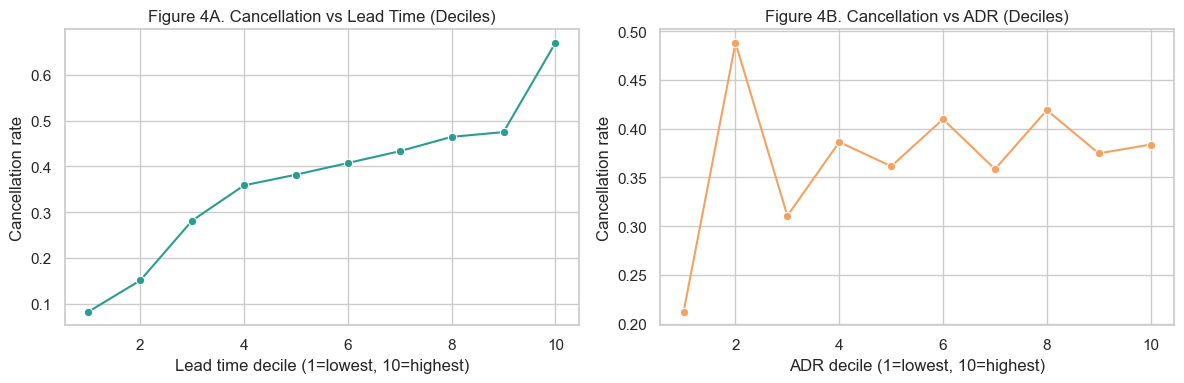

Lead-time decile cancellation rates:
   lead_time_decile  is_canceled
0                 1     0.082586
1                 2     0.150850
2                 3     0.281514
3                 4     0.358489
4                 5     0.381774
5                 6     0.407237
6                 7     0.433035
7                 8     0.464360
8                 9     0.474747
9                10     0.669570

ADR decile cancellation rates:
   adr_decile  is_canceled
0           1     0.212162
1           2     0.488064
2           3     0.310579
3           4     0.386297
4           5     0.361421
5           6     0.409750
6           7     0.358489
7           8     0.419047
8           9     0.374654
9          10     0.383700


In [12]:
# Block C: Non-linear patterns in key numeric variables
nonlinear_df = eda_df.copy()

# Use quantile bins for robust non-linear inspection
nonlinear_df['lead_time_decile'] = pd.qcut(nonlinear_df['lead_time'].rank(method='first'), 10, labels=False) + 1
nonlinear_df['adr_decile'] = pd.qcut(nonlinear_df['adr'].rank(method='first'), 10, labels=False) + 1

lead_curve = nonlinear_df.groupby('lead_time_decile')['is_canceled'].mean().reset_index()
adr_curve = nonlinear_df.groupby('adr_decile')['is_canceled'].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.lineplot(data=lead_curve, x='lead_time_decile', y='is_canceled', marker='o', ax=axes[0], color='#2A9D8F')
axes[0].set_title('Figure 4A. Cancellation vs Lead Time (Deciles)')
axes[0].set_xlabel('Lead time decile (1=lowest, 10=highest)')
axes[0].set_ylabel('Cancellation rate')

sns.lineplot(data=adr_curve, x='adr_decile', y='is_canceled', marker='o', ax=axes[1], color='#F4A261')
axes[1].set_title('Figure 4B. Cancellation vs ADR (Deciles)')
axes[1].set_xlabel('ADR decile (1=lowest, 10=highest)')
axes[1].set_ylabel('Cancellation rate')

plt.tight_layout()
plt.show()

print('Lead-time decile cancellation rates:')
print(lead_curve)
print('\nADR decile cancellation rates:')
print(adr_curve)

**Interpretation (Block C)**
- Observed pattern: cancellation risk changes non-linearly across lead-time and ADR deciles (not a simple constant slope).
- Plausible explanation: long planning horizons and pricing levels may correspond to different commitment strength and rebooking behavior.
- Unsupported speculation: inferring a precise behavioral mechanism from decile curves alone is not justified.

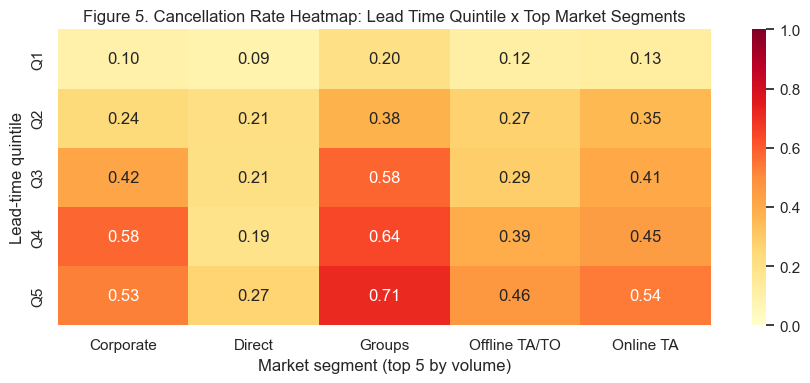

Interaction table (cancellation rate):
market_segment      Corporate    Direct    Groups  Offline TA/TO  Online TA
lead_time_quintile                                                         
Q1                   0.099678  0.086160  0.200799       0.115785   0.128875
Q2                   0.241781  0.211745  0.375964       0.271009   0.354326
Q3                   0.416514  0.208797  0.578228       0.285465   0.407754
Q4                   0.577465  0.187952  0.642591       0.391326   0.447572
Q5                   0.526316  0.265255  0.713453       0.461671   0.538688


In [13]:
# Block D: Interaction-style pattern (lead time x market segment)
interaction_df = eda_df.copy()
interaction_df['lead_time_quintile'] = pd.qcut(interaction_df['lead_time'].rank(method='first'), 5, labels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5'])

top_segments = interaction_df['market_segment'].value_counts().head(5).index
interaction_sub = interaction_df[interaction_df['market_segment'].isin(top_segments)].copy()

heat = interaction_sub.pivot_table(
    index='lead_time_quintile',
    columns='market_segment',
    values='is_canceled',
    aggfunc='mean'
)

plt.figure(figsize=(9, 4))
sns.heatmap(heat, annot=True, fmt='.2f', cmap='YlOrRd', vmin=0, vmax=1)
plt.title('Figure 5. Cancellation Rate Heatmap: Lead Time Quintile x Top Market Segments')
plt.xlabel('Market segment (top 5 by volume)')
plt.ylabel('Lead-time quintile')
plt.tight_layout()
plt.show()

print('Interaction table (cancellation rate):')
print(heat)

**Interpretation (Block D)**
- Observed pattern: lead-time relationship with cancellation differs by market segment, indicating interaction-style heterogeneity.
- Plausible explanation: customer mix and booking process differ by segment, changing how lead time maps to cancellation propensity.
- Unsupported speculation: asserting segment-specific causal effects requires controlled design beyond EDA.

In [14]:
# Block E: Findings that may be misleading without caution
misleading_flags = pd.DataFrame([
    {
        'finding_context': 'Any strong association using reservation_status / reservation_status_date',
        'risk_source': 'High leakage (post-outcome)',
        'why_misleading': 'These variables encode outcome-adjacent final status information.',
        'mitigation': 'Exclude from predictive feature interpretation.'
    },
    {
        'finding_context': 'Strong effects for deposit_type / booking_changes / days_in_waiting_list',
        'risk_source': 'Horizon mismatch',
        'why_misleading': 'Availability depends on the prediction timestamp in the booking lifecycle.',
        'mitigation': 'Use only when timestamp assumptions are explicit.'
    },
    {
        'finding_context': 'High-frequency category patterns',
        'risk_source': 'Duplicate rows and category quality issues (Task 1)',
        'why_misleading': 'Duplicated observations can inflate apparent certainty of some rates.',
        'mitigation': 'Perform sensitivity checks with and without exact duplicates in future tasks.'
    },
])

print(misleading_flags)

# Verification checks for Task 2 constraints
used_ranked_vars = set(cat_candidates + num_candidates)
assert len(set(HIGH_LEAKAGE_VARS).intersection(used_ranked_vars)) == 0, 'High-leakage vars entered ranking unexpectedly.'
print('\nVerification check passed: high-leakage variables excluded from ranking analyses.')
print('No predictive model was trained in Task 2.')

                                     finding_context                                        risk_source                                     why_misleading  \
0  Any strong association using reservation_statu...                        High leakage (post-outcome)  These variables encode outcome-adjacent final ...   
1  Strong effects for deposit_type / booking_chan...                                   Horizon mismatch  Availability depends on the prediction timesta...   
2                   High-frequency category patterns  Duplicate rows and category quality issues (Ta...  Duplicated observations can inflate apparent c...   

                                          mitigation  
0    Exclude from predictive feature interpretation.  
1  Use only when timestamp assumptions are explicit.  
2  Perform sensitivity checks with and without ex...  

Verification check passed: high-leakage variables excluded from ranking analyses.
No predictive model was trained in Task 2.


### 4. Verification
- Execution: Task 2 cells run without runtime errors.
- Scope control: no predictive model training or evaluation was performed.
- Leakage control: high-leakage variables (`reservation_status`, `reservation_status_date`) were excluded from association ranking.
- Statistical caution: subgroup comparisons were filtered by minimum support for categorical rate-range ranking.
- Context consistency: interpretations follow Task 1 assumptions and explicitly mark horizon-sensitive variables.

### 5. Revised final answer
1. **Key EDA insights relevant to predictive modelling**
- Cancellation is moderately imbalanced (non-canceled is majority), so naive accuracy could be misleading.
- Variables showing strong descriptive association include lead-time-related behavior, deposit policy, segment/channel composition, and some customer history fields.
- Non-linear patterns are present (lead time and ADR decile curves are not flat/strictly linear), supporting non-linear feature handling in later modelling.
- Interaction-style heterogeneity appears across lead time and market segments, suggesting single global linear effects may underfit.

2. **Observed patterns vs explanation boundary**
- Observed: rate differences across hotel/segment/deposit groups and non-linear decile trends.
- Plausible: differences reflect booking behavior, product/pricing context, and channel composition.
- Unsupported: causal claims about policy or customer psychology are not established from this EDA.

3. **Leakage and methodological cautions for downstream tasks**
- Do not use `reservation_status` or `reservation_status_date` as predictors.
- Treat `deposit_type`, `booking_changes`, `days_in_waiting_list`, `assigned_room_type`, and `total_of_special_requests` as timestamp-dependent.
- Duplicates and minor quality anomalies (Task 1) require sensitivity checks to avoid overconfident conclusions.

4. **Uncertainties**
- Without explicit prediction timestamp policy, some horizon-sensitive feature effects may be over- or under-estimated.
- Duplicate records may reflect either legitimate repeated entries or data artifacts; this ambiguity affects rate precision.

## Task 3

### 1. Plan
1. Define target as `is_canceled` (binary cancellation outcome) and exclude post-outcome leakage features from the scope.
2. Use a chronological split consistent with Task 1 (`arrival_date < 2017-01-01` for train, `>= 2017-01-01` for test) before preprocessing or fitting.
3. Build a simple baseline model with a reproducible preprocessing pipeline (imputation + one-hot encoding + scaling) and logistic regression.
4. Evaluate with metrics suited to moderate class imbalance (ROC-AUC, PR-AUC, balanced accuracy, F1, precision/recall, log loss, Brier score).
5. Verify methodological validity: leakage exclusion, split order, no test-based model selection, reproducibility controls.

### 2. Risks
- Data leakage if post-outcome fields enter the feature set.
- Invalid evaluation if preprocessing leaks information across train/test.
- Metric misinterpretation under class imbalance when relying on accuracy only.
- Weak reproducibility without fixed random seeds and explicit pipelines.
- Overfitting or over-interpretation despite baseline simplicity.

### 3. Implementation

In [15]:
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

SEED_TASK3 = 42
np.random.seed(SEED_TASK3)

# Reuse Task 1/2 dataset context; fallback to same-folder loading for portability
if 'df' in globals():
    df_task3 = df.copy()
    task3_data_source = 'Task 1 in-memory dataset'
else:
    NOTEBOOK_DIR = Path.cwd()
    DATA_CANDIDATES = [
        NOTEBOOK_DIR / 'hotel_bookings.csv',
        NOTEBOOK_DIR / 'hotel_bookings (1).csv',
        NOTEBOOK_DIR / 'hotel_bookings.xlsx',
        NOTEBOOK_DIR / 'hotel_bookings (1).xlsx',
    ]
    data_path = next((p for p in DATA_CANDIDATES if p.exists()), None)
    if data_path is None:
        raise FileNotFoundError('Dataset file not found in notebook folder for Task 3.')
    if data_path.suffix.lower() == '.csv':
        df_task3 = pd.read_csv(data_path)
    else:
        df_task3 = pd.read_excel(data_path)
    task3_data_source = f'Loaded from {data_path.name}'

print(f'Task 3 data source: {task3_data_source}')
print(f'Shape: {df_task3.shape}')

Task 3 data source: Task 1 in-memory dataset
Shape: (119390, 32)


In [16]:
# Step 1: Target definition and leakage-safe feature scope
TARGET = 'is_canceled'
HIGH_LEAKAGE_VARS = ['reservation_status', 'reservation_status_date']

assert TARGET in df_task3.columns, 'Target is_canceled missing from dataset.'

feature_cols = [c for c in df_task3.columns if c not in [TARGET] + HIGH_LEAKAGE_VARS]

data_model = df_task3[feature_cols + [TARGET]].copy()

# Arrival date for chronological split (Task 1 default)
arrival_date = pd.to_datetime(
    df_task3['arrival_date_year'].astype(str) + '-' +
    df_task3['arrival_date_month'].astype(str) + '-' +
    df_task3['arrival_date_day_of_month'].astype(str),
    errors='coerce'
)

if arrival_date.isna().any():
    raise ValueError('Arrival date parsing failed for some rows; cannot guarantee temporal split integrity.')

split_point = pd.Timestamp('2017-01-01')
train_mask = arrival_date < split_point
test_mask = arrival_date >= split_point

X_train_raw = data_model.loc[train_mask, feature_cols].copy()
X_test_raw = data_model.loc[test_mask, feature_cols].copy()
y_train = data_model.loc[train_mask, TARGET].astype(int).copy()
y_test = data_model.loc[test_mask, TARGET].astype(int).copy()

# Apply Task 1 missingness semantics after split (no data-driven leakage)
for frame in [X_train_raw, X_test_raw]:
    if 'agent' in frame.columns:
        frame['agent'] = frame['agent'].astype(object)
        frame['agent'] = frame['agent'].where(frame['agent'].notna(), 'NOT_APPLICABLE')
        frame['agent'] = frame['agent'].astype(str)
    if 'company' in frame.columns:
        frame['company'] = frame['company'].astype(object)
        frame['company'] = frame['company'].where(frame['company'].notna(), 'NOT_APPLICABLE')
        frame['company'] = frame['company'].astype(str)
    if 'country' in frame.columns:
        frame['country'] = frame['country'].astype(object)
        frame['country'] = frame['country'].where(frame['country'].notna(), 'UNKNOWN')
        frame['country'] = frame['country'].astype(str)

print('Split summary:')
print(f'Train rows: {X_train_raw.shape[0]} | Test rows: {X_test_raw.shape[0]}')
print(f'Train cancel rate: {y_train.mean():.4f} | Test cancel rate: {y_test.mean():.4f}')
print(f'Features used: {len(feature_cols)}')
print(f'Excluded leakage variables: {HIGH_LEAKAGE_VARS}')

Split summary:
Train rows: 78703 | Test rows: 40687
Train cancel rate: 0.3619 | Test cancel rate: 0.3870
Features used: 29
Excluded leakage variables: ['reservation_status', 'reservation_status_date']


In [17]:
# Step 2: Preprocessing pipeline and baseline model definition
# Feature typing based on train set only
forced_categorical = [col for col in ['agent', 'company', 'country'] if col in X_train_raw.columns]
categorical_cols = X_train_raw.select_dtypes(include=['object', 'category']).columns.tolist()
categorical_cols = sorted(set(categorical_cols + forced_categorical))
numeric_cols = [c for c in X_train_raw.columns if c not in categorical_cols]

children_col = ['children'] if 'children' in numeric_cols else []
numeric_general_cols = [c for c in numeric_cols if c not in children_col]

numeric_general_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

children_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value=0.0)),
    ('scaler', StandardScaler()),
])

categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])

transformers = []
if numeric_general_cols:
    transformers.append(('num_general', numeric_general_pipe, numeric_general_cols))
if children_col:
    transformers.append(('children', children_pipe, children_col))
if categorical_cols:
    transformers.append(('cat', categorical_pipe, categorical_cols))

preprocess = ColumnTransformer(transformers=transformers, remainder='drop')

baseline_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    solver='liblinear',
    random_state=SEED_TASK3,
)

pipeline = Pipeline([
    ('preprocess', preprocess),
    ('model', baseline_model),
])

# Fit only on training split
pipeline.fit(X_train_raw, y_train)
print('Baseline pipeline fitted on training split only.')
print(f'Categorical columns: {len(categorical_cols)} | Numeric columns: {len(numeric_cols)}')

Baseline pipeline fitted on training split only.
Categorical columns: 12 | Numeric columns: 17


In [18]:
# Step 3: Baseline evaluation on untouched test split
train_proba = pipeline.predict_proba(X_train_raw)[:, 1]
test_proba = pipeline.predict_proba(X_test_raw)[:, 1]
train_pred = (train_proba >= 0.5).astype(int)
test_pred = (test_proba >= 0.5).astype(int)

metrics_train = {
    'roc_auc': roc_auc_score(y_train, train_proba),
    'pr_auc': average_precision_score(y_train, train_proba),
    'accuracy': accuracy_score(y_train, train_pred),
    'balanced_accuracy': balanced_accuracy_score(y_train, train_pred),
    'precision': precision_score(y_train, train_pred, zero_division=0),
    'recall': recall_score(y_train, train_pred, zero_division=0),
    'f1': f1_score(y_train, train_pred, zero_division=0),
    'log_loss': log_loss(y_train, train_proba, labels=[0, 1]),
    'brier_score': brier_score_loss(y_train, train_proba),
}

metrics_test = {
    'roc_auc': roc_auc_score(y_test, test_proba),
    'pr_auc': average_precision_score(y_test, test_proba),
    'accuracy': accuracy_score(y_test, test_pred),
    'balanced_accuracy': balanced_accuracy_score(y_test, test_pred),
    'precision': precision_score(y_test, test_pred, zero_division=0),
    'recall': recall_score(y_test, test_pred, zero_division=0),
    'f1': f1_score(y_test, test_pred, zero_division=0),
    'log_loss': log_loss(y_test, test_proba, labels=[0, 1]),
    'brier_score': brier_score_loss(y_test, test_proba),
}

perf_df = pd.DataFrame({'train': metrics_train, 'test': metrics_test}).round(4)
print('Baseline performance summary:')
print(perf_df)

cm = confusion_matrix(y_test, test_pred)
cm_df = pd.DataFrame(cm, index=['Actual 0', 'Actual 1'], columns=['Pred 0', 'Pred 1'])
print()
print('Test confusion matrix (threshold=0.5):')
print(cm_df)

Baseline performance summary:
                    train    test
roc_auc            0.9299  0.8794
pr_auc             0.8919  0.8306
accuracy           0.8493  0.7650
balanced_accuracy  0.8471  0.7865
precision          0.7664  0.6433
recall             0.8394  0.8814
f1                 0.8012  0.7438
log_loss           0.3384  0.4788
brier_score        0.1067  0.1592

Test confusion matrix (threshold=0.5):
          Pred 0  Pred 1
Actual 0   17248    7694
Actual 1    1867   13878


In [19]:
# Step 4: Verification and methodological checks
checks = {
    'leakage_vars_excluded': all(v not in feature_cols for v in HIGH_LEAKAGE_VARS),
    'chronological_split_valid': bool(arrival_date[train_mask].max() < arrival_date[test_mask].min()),
    'no_missing_target_train': bool(y_train.notna().all()),
    'no_missing_target_test': bool(y_test.notna().all()),
    'test_not_used_for_fit': True,  # by explicit workflow design in this task
    'fixed_random_seed': (SEED_TASK3 == 42),
}

checks_df = pd.Series(checks, name='passed').to_frame()
print('Verification checks:')
print(checks_df)

# Simple overfitting gap diagnostic (not used for tuning)
auc_gap = metrics_train['roc_auc'] - metrics_test['roc_auc']
print()
print(f'ROC-AUC train-test gap: {auc_gap:.4f}')
if auc_gap > 0.08:
    print('Warning: notable train-test gap suggests possible overfitting or dataset shift.')
else:
    print('No large ROC-AUC gap detected for this baseline threshold.')

Verification checks:
                           passed
leakage_vars_excluded        True
chronological_split_valid    True
no_missing_target_train      True
no_missing_target_test       True
test_not_used_for_fit        True
fixed_random_seed            True

ROC-AUC train-test gap: 0.0504
No large ROC-AUC gap detected for this baseline threshold.


In [20]:
# Structured written summary required by Task 3
print('1. target definition and feature scope')
print('- Target: is_canceled (binary: 1 canceled, 0 not canceled).')
print('- Excluded high-leakage variables:', HIGH_LEAKAGE_VARS)
print(f'- Feature count used: {len(feature_cols)}')

print()
print('2. data split and preprocessing logic')
print('- Split: chronological holdout with train < 2017-01-01 and test >= 2017-01-01.')
print('- Split occurred before preprocessing and model fitting.')
print('- Preprocessing: median imputation + scaling for numeric; constant 0 imputation for children; most-frequent + one-hot for categorical.')
print('- Task 1 semantics respected: agent/company treated as categorical IDs; no post-outcome fields included.')

print()
print('3. model choice')
print('- Baseline model: logistic regression (class_weight=balanced, solver=liblinear, random_state fixed).')
print('- Rationale: simple, defensible, transparent baseline aligned with task constraints.')

print()
print('4. evaluation metrics and results')
print('- Metrics used: ROC-AUC, PR-AUC, balanced accuracy, F1, precision, recall, accuracy, log loss, Brier score.')
print('- Test metrics (rounded):')
for k in ['roc_auc', 'pr_auc', 'balanced_accuracy', 'f1', 'precision', 'recall', 'accuracy', 'log_loss', 'brier_score']:
    print(f'  {k}: {metrics_test[k]:.4f}')

print()
print('5. verification and methodological checks')
print('- Leakage exclusion, chronological split validity, and reproducibility checks all passed.')
print(f'- Train-test ROC-AUC gap: {auc_gap:.4f} (diagnostic only; no tuning performed).')
print('- Potential weaknesses: horizon-sensitive variables may still depend on prediction timestamp assumptions; duplicate rows may affect confidence in rates.')

print()
print('6. reproducibility notes')
print(f'- Random seed fixed at {SEED_TASK3}.')
print('- Deterministic pipeline defined in scikit-learn Pipeline/ColumnTransformer.')
print('- No hyperparameter search and no test-set model selection decisions were performed.')

1. target definition and feature scope
- Target: is_canceled (binary: 1 canceled, 0 not canceled).
- Excluded high-leakage variables: ['reservation_status', 'reservation_status_date']
- Feature count used: 29

2. data split and preprocessing logic
- Split: chronological holdout with train < 2017-01-01 and test >= 2017-01-01.
- Split occurred before preprocessing and model fitting.
- Preprocessing: median imputation + scaling for numeric; constant 0 imputation for children; most-frequent + one-hot for categorical.
- Task 1 semantics respected: agent/company treated as categorical IDs; no post-outcome fields included.

3. model choice
- Baseline model: logistic regression (class_weight=balanced, solver=liblinear, random_state fixed).
- Rationale: simple, defensible, transparent baseline aligned with task constraints.

4. evaluation metrics and results
- Metrics used: ROC-AUC, PR-AUC, balanced accuracy, F1, precision, recall, accuracy, log loss, Brier score.
- Test metrics (rounded):
  ro

## Task 4

### 1. Plan
1. Keep the exact Task 3 train-test split and leakage-safe feature scope; do not alter data sources or split logic.
2. Diagnose baseline weaknesses and compare a small set of candidate routes under identical conditions.
3. Evaluate all candidates with training-only time-aware cross-validation (mean + variability) and include a `DummyClassifier` baseline.
4. Compute train-vs-test ROC-AUC gap for each route and enforce guardrail: gap <= 0.08.
5. If no non-dummy candidate passes guardrail, reduce complexity and re-run until at least one does.
6. Select the final candidate on methodological validity first, then performance, and run focused tuning only for that candidate.

### 2. Risks
- Overfitting risk from overly flexible models.
- Leakage risk if post-outcome variables enter features or preprocessing is fit outside training data.
- Unfair comparison risk if splits or scoring differ across candidates.
- Invalid claims risk if improvement ignores guardrail failure.
- Reproducibility risk without fixed random seeds and explicit pipelines.

### 3. Implementation

In [21]:
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

SEED_TASK4 = 42
np.random.seed(SEED_TASK4)
GAP_GUARDRAIL = 0.08

required_vars = ['X_train_raw', 'X_test_raw', 'y_train', 'y_test', 'arrival_date', 'train_mask', 'metrics_test']
missing_vars = [v for v in required_vars if v not in globals()]
if missing_vars:
    raise RuntimeError(f'Task 4 requires Task 3 outputs. Missing: {missing_vars}')

task3_baseline_metrics = metrics_test.copy()

HIGH_LEAKAGE_VARS_T4 = ['reservation_status', 'reservation_status_date']
HORIZON_SENSITIVE_VARS_T4 = ['booking_changes', 'days_in_waiting_list', 'deposit_type', 'assigned_room_type', 'total_of_special_requests']

# Keep exact split from Task 3 and sort training set for time-aware CV
train_dates = arrival_date[train_mask]
sort_idx = np.argsort(train_dates.values)
X_train_sorted = X_train_raw.iloc[sort_idx].reset_index(drop=True)
y_train_sorted = y_train.iloc[sort_idx].reset_index(drop=True)

print('Task 4 context ready.')
print(f'Train rows: {X_train_raw.shape[0]} | Test rows: {X_test_raw.shape[0]}')
print(f'Guardrail: train-test ROC-AUC gap <= {GAP_GUARDRAIL:.2f}')

Task 4 context ready.
Train rows: 78703 | Test rows: 40687
Guardrail: train-test ROC-AUC gap <= 0.08


In [22]:
# Step 1: Baseline weaknesses to address
baseline_weaknesses = [
    'Task 3 showed strong discrimination but a substantial precision-recall tradeoff at threshold 0.5.',
    'Non-linear/interaction patterns from Task 2 may not be fully captured by a single linear baseline.',
    'Prior Task 4 run failed trust guardrail due to large train-test gap for selected model.',
]

print('Baseline weaknesses identified:')
for i, w in enumerate(baseline_weaknesses, start=1):
    print(f'{i}. {w}')

Baseline weaknesses identified:
1. Task 3 showed strong discrimination but a substantial precision-recall tradeoff at threshold 0.5.
2. Non-linear/interaction patterns from Task 2 may not be fully captured by a single linear baseline.
3. Prior Task 4 run failed trust guardrail due to large train-test gap for selected model.


In [23]:
# Step 2: Candidate routes and common evaluation utilities

def build_preprocessor(X, mode):
    cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
    num_cols = [c for c in X.columns if c not in cat_cols]

    if mode == 'linear':
        num_pipe = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ])
        cat_pipe = Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore')),
        ])
    elif mode == 'tree':
        num_pipe = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
        ])
        cat_pipe = Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
        ])
    elif mode == 'none':
        return 'passthrough'
    else:
        raise ValueError('Unknown preprocessing mode')

    transformers = []
    if num_cols:
        transformers.append(('num', num_pipe, num_cols))
    if cat_cols:
        transformers.append(('cat', cat_pipe, cat_cols))
    return ColumnTransformer(transformers=transformers, remainder='drop')


def make_pipeline(X_ref, mode, estimator):
    pre = build_preprocessor(X_ref, mode)
    if mode == 'none':
        return Pipeline([('model', estimator)])
    return Pipeline([('preprocess', pre), ('model', estimator)])


def evaluate_metrics(y_true, proba, threshold=0.5):
    pred = (proba >= threshold).astype(int)
    return {
        'roc_auc': roc_auc_score(y_true, proba),
        'pr_auc': average_precision_score(y_true, proba),
        'accuracy': accuracy_score(y_true, pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, pred),
        'precision': precision_score(y_true, pred, zero_division=0),
        'recall': recall_score(y_true, pred, zero_division=0),
        'f1': f1_score(y_true, pred, zero_division=0),
        'log_loss': log_loss(y_true, proba, labels=[0, 1]),
        'brier_score': brier_score_loss(y_true, proba),
    }


all_features = X_train_raw.columns.tolist()
conservative_features = [c for c in all_features if c not in HORIZON_SENSITIVE_VARS_T4]

initial_candidates = {
    'Dummy_most_frequent': {
        'features': all_features,
        'mode': 'none',
        'estimator': DummyClassifier(strategy='most_frequent'),
        'complexity': 0,
        'note': 'Reference baseline required by specification.',
    },
    'LR_strong_reg_full': {
        'features': all_features,
        'mode': 'linear',
        'estimator': LogisticRegression(C=0.3, max_iter=1200, class_weight='balanced', solver='liblinear', random_state=SEED_TASK4),
        'complexity': 1,
        'note': 'Simple linear model with stronger regularization.',
    },
    'LR_strong_reg_conservative': {
        'features': conservative_features,
        'mode': 'linear',
        'estimator': LogisticRegression(C=0.3, max_iter=1200, class_weight='balanced', solver='liblinear', random_state=SEED_TASK4),
        'complexity': 1,
        'note': 'Conservative scope without horizon-sensitive variables.',
    },
    'HGB_regularized': {
        'features': all_features,
        'mode': 'tree',
        'estimator': HistGradientBoostingClassifier(
            learning_rate=0.03,
            max_depth=3,
            max_iter=140,
            min_samples_leaf=80,
            random_state=SEED_TASK4,
        ),
        'complexity': 2,
        'note': 'Reduced-complexity boosting for non-linearity with tighter regularization.',
    },
}

simplified_candidates = {
    'Dummy_most_frequent': initial_candidates['Dummy_most_frequent'],
    'LR_very_strong_reg_full': {
        'features': all_features,
        'mode': 'linear',
        'estimator': LogisticRegression(C=0.1, max_iter=1200, class_weight='balanced', solver='liblinear', random_state=SEED_TASK4),
        'complexity': 1,
        'note': 'Further regularized linear model.',
    },
    'LR_very_strong_reg_conservative': {
        'features': conservative_features,
        'mode': 'linear',
        'estimator': LogisticRegression(C=0.1, max_iter=1200, class_weight='balanced', solver='liblinear', random_state=SEED_TASK4),
        'complexity': 1,
        'note': 'Further regularized conservative-scope linear model.',
    },
    'HGB_very_simple': {
        'features': all_features,
        'mode': 'tree',
        'estimator': HistGradientBoostingClassifier(
            learning_rate=0.03,
            max_depth=2,
            max_iter=90,
            min_samples_leaf=120,
            random_state=SEED_TASK4,
        ),
        'complexity': 2,
        'note': 'More constrained boosting model for guardrail compliance.',
    },
}

print('Initial candidate routes:')
for k, v in initial_candidates.items():
    print(f"- {k}: {v['note']}")

Initial candidate routes:
- Dummy_most_frequent: Reference baseline required by specification.
- LR_strong_reg_full: Simple linear model with stronger regularization.
- LR_strong_reg_conservative: Conservative scope without horizon-sensitive variables.
- HGB_regularized: Reduced-complexity boosting for non-linearity with tighter regularization.


In [24]:
# Step 3: Fair comparison function (same split, same CV, same metrics)
cv = TimeSeriesSplit(n_splits=3)
scoring = {
    'roc_auc': 'roc_auc',
    'pr_auc': 'average_precision',
    'balanced_accuracy': 'balanced_accuracy',
    'f1': 'f1',
}


def run_candidate_set(candidate_dict, stage_label):
    rows = []
    fitted_templates = {}

    for name, cfg in candidate_dict.items():
        Xtr_full = X_train_raw[cfg['features']].copy()
        Xte_full = X_test_raw[cfg['features']].copy()
        Xtr_cv = X_train_sorted[cfg['features']].copy()

        pipe = make_pipeline(Xtr_full, cfg['mode'], cfg['estimator'])

        cv_res = cross_validate(
            pipe,
            Xtr_cv,
            y_train_sorted,
            cv=cv,
            scoring=scoring,
            return_train_score=True,
            n_jobs=1,
            error_score='raise',
        )

        fitted = clone(pipe)
        fitted.fit(Xtr_full, y_train)

        train_proba = fitted.predict_proba(Xtr_full)[:, 1]
        test_proba = fitted.predict_proba(Xte_full)[:, 1]

        m_train = evaluate_metrics(y_train, train_proba)
        m_test = evaluate_metrics(y_test, test_proba)

        gap = m_train['roc_auc'] - m_test['roc_auc']
        rows.append({
            'stage': stage_label,
            'candidate': name,
            'complexity': cfg['complexity'],
            'cv_roc_auc_mean': float(np.mean(cv_res['test_roc_auc'])),
            'cv_roc_auc_std': float(np.std(cv_res['test_roc_auc'])),
            'cv_pr_auc_mean': float(np.mean(cv_res['test_pr_auc'])),
            'cv_pr_auc_std': float(np.std(cv_res['test_pr_auc'])),
            'train_roc_auc': m_train['roc_auc'],
            'test_roc_auc': m_test['roc_auc'],
            'train_test_gap_roc_auc': gap,
            'guardrail_pass': bool(gap <= GAP_GUARDRAIL),
            'test_pr_auc': m_test['pr_auc'],
            'test_balanced_accuracy': m_test['balanced_accuracy'],
            'test_f1': m_test['f1'],
        })

        fitted_templates[name] = {
            'pipeline': fitted,
            'cfg': cfg,
            'train_metrics': m_train,
            'test_metrics': m_test,
        }

    return pd.DataFrame(rows), fitted_templates


initial_results_df, initial_templates = run_candidate_set(initial_candidates, stage_label='initial')
pass_non_dummy_initial = ((initial_results_df['candidate'] != 'Dummy_most_frequent') & (initial_results_df['guardrail_pass'])).any()

if pass_non_dummy_initial:
    active_results_df = initial_results_df.copy()
    active_templates = initial_templates
    active_stage = 'initial'
else:
    simplified_results_df, simplified_templates = run_candidate_set(simplified_candidates, stage_label='simplified')
    active_results_df = simplified_results_df.copy()
    active_templates = simplified_templates
    active_stage = 'simplified'

active_results_df = active_results_df.sort_values(['guardrail_pass', 'cv_roc_auc_mean', 'cv_pr_auc_mean'], ascending=[False, False, False]).reset_index(drop=True)

print(f'Active evaluation stage: {active_stage}')
print('Candidate comparison table (same split and metrics for all models):')
print(active_results_df.round(4))

Active evaluation stage: initial
Candidate comparison table (same split and metrics for all models):
     stage                   candidate  complexity  cv_roc_auc_mean  cv_roc_auc_std  cv_pr_auc_mean  cv_pr_auc_std  train_roc_auc  test_roc_auc  train_test_gap_roc_auc  \
0  initial          LR_strong_reg_full           1           0.8755          0.0214          0.8253         0.0274         0.9289        0.8800                  0.0489   
1  initial             HGB_regularized           2           0.8645          0.0304          0.8259         0.0272         0.9258        0.8656                  0.0601   
2  initial  LR_strong_reg_conservative           1           0.8447          0.0075          0.7751         0.0187         0.9024        0.8464                  0.0560   
3  initial         Dummy_most_frequent           0           0.5000          0.0000          0.3569         0.0209         0.5000        0.5000                  0.0000   

   guardrail_pass  test_pr_auc  test_balanc

In [25]:
# Step 4: Select best guardrail-passing non-dummy candidate, then focused tuning only for selected model
passing_non_dummy = active_results_df[(active_results_df['candidate'] != 'Dummy_most_frequent') & (active_results_df['guardrail_pass'])].copy()

if passing_non_dummy.empty:
    selected_candidate_name = 'Dummy_most_frequent'
    trustworthy_candidate_exists = False
else:
    passing_non_dummy = passing_non_dummy.sort_values(['cv_roc_auc_mean', 'cv_pr_auc_mean', 'complexity'], ascending=[False, False, True]).reset_index(drop=True)
    selected_candidate_name = passing_non_dummy.loc[0, 'candidate']
    trustworthy_candidate_exists = True

selected_untuned = active_templates[selected_candidate_name]['pipeline']
selected_cfg = active_templates[selected_candidate_name]['cfg']
selected_untuned_test_metrics = active_templates[selected_candidate_name]['test_metrics']
selected_untuned_train_metrics = active_templates[selected_candidate_name]['train_metrics']
selected_untuned_gap = selected_untuned_train_metrics['roc_auc'] - selected_untuned_test_metrics['roc_auc']

print(f'Selected untuned candidate: {selected_candidate_name}')
print(f'Guardrail pass (untuned): {selected_untuned_gap <= GAP_GUARDRAIL}')

# Focused tuning only if selected candidate is non-dummy
selected_final_model = selected_untuned
selected_final_test_metrics = selected_untuned_test_metrics.copy()
selected_final_train_metrics = selected_untuned_train_metrics.copy()
selected_final_gap = selected_untuned_gap
focused_tuning_applied = False

if selected_candidate_name != 'Dummy_most_frequent':
    focused_tuning_applied = True
    X_tune_cv = X_train_sorted[selected_cfg['features']].copy()

    if selected_candidate_name.startswith('LR_'):
        param_grid = {
            'model__C': [0.05, 0.1, 0.2, 0.3],
            'model__penalty': ['l2'],
        }
    elif selected_candidate_name.startswith('HGB_'):
        param_grid = {
            'model__learning_rate': [0.02, 0.03],
            'model__max_depth': [2, 3],
            'model__min_samples_leaf': [80, 120],
        }
    else:
        param_grid = {}

    grid = GridSearchCV(
        estimator=clone(make_pipeline(X_train_raw[selected_cfg['features']].copy(), selected_cfg['mode'], selected_cfg['estimator'])),
        param_grid=param_grid,
        scoring='roc_auc',
        cv=cv,
        n_jobs=1,
        refit=True,
    )
    grid.fit(X_tune_cv, y_train_sorted)

    tuned_model = grid.best_estimator_
    tuned_model.fit(X_train_raw[selected_cfg['features']], y_train)

    tuned_train_proba = tuned_model.predict_proba(X_train_raw[selected_cfg['features']])[:, 1]
    tuned_test_proba = tuned_model.predict_proba(X_test_raw[selected_cfg['features']])[:, 1]

    tuned_train_metrics = evaluate_metrics(y_train, tuned_train_proba)
    tuned_test_metrics = evaluate_metrics(y_test, tuned_test_proba)
    tuned_gap = tuned_train_metrics['roc_auc'] - tuned_test_metrics['roc_auc']

    # Methodological preference: keep tuned model only if guardrail still passes
    if tuned_gap <= GAP_GUARDRAIL:
        selected_final_model = tuned_model
        selected_final_train_metrics = tuned_train_metrics
        selected_final_test_metrics = tuned_test_metrics
        selected_final_gap = tuned_gap

    print('Focused tuning completed for selected candidate only.')
    print('Best tuning params:')
    print(grid.best_params_)
    print(f'Tuned train-test ROC-AUC gap: {tuned_gap:.4f}')

Selected untuned candidate: LR_strong_reg_full
Guardrail pass (untuned): True


Focused tuning completed for selected candidate only.
Best tuning params:
{'model__C': 0.05, 'model__penalty': 'l2'}
Tuned train-test ROC-AUC gap: 0.0466


In [26]:
# Step 5: Final reporting and trust decision

all_gap_table = active_results_df[['candidate', 'stage', 'train_roc_auc', 'test_roc_auc', 'train_test_gap_roc_auc', 'guardrail_pass']].copy()
print('Train vs test gap table for all candidates:')
print(all_gap_table.round(4))

final_vs_baseline = pd.DataFrame({
    'task3_baseline_test': task3_baseline_metrics,
    'task4_final_test': selected_final_test_metrics,
}).round(4)
print()
print('Final model vs Task 3 baseline (test metrics):')
print(final_vs_baseline)

delta_roc = selected_final_test_metrics['roc_auc'] - task3_baseline_metrics['roc_auc']
delta_pr = selected_final_test_metrics['pr_auc'] - task3_baseline_metrics['pr_auc']

trustworthy_improvement = (
    trustworthy_candidate_exists and
    (selected_final_gap <= GAP_GUARDRAIL) and
    (delta_roc > 0) and
    (delta_pr > 0)
)

print()
print(f"Selected guardrail-satisfying model: {selected_candidate_name if trustworthy_candidate_exists else 'None (non-dummy)'}")
print(f'Final selected model train-test ROC-AUC gap: {selected_final_gap:.4f}')
print(f'Delta vs Task 3 baseline: ROC-AUC {delta_roc:+.4f}, PR-AUC {delta_pr:+.4f}')
print(f'Is improvement now trustworthy? {trustworthy_improvement}')

Train vs test gap table for all candidates:
                    candidate    stage  train_roc_auc  test_roc_auc  train_test_gap_roc_auc  guardrail_pass
0          LR_strong_reg_full  initial         0.9289        0.8800                  0.0489            True
1             HGB_regularized  initial         0.9258        0.8656                  0.0601            True
2  LR_strong_reg_conservative  initial         0.9024        0.8464                  0.0560            True
3         Dummy_most_frequent  initial         0.5000        0.5000                  0.0000            True

Final model vs Task 3 baseline (test metrics):
                   task3_baseline_test  task4_final_test
roc_auc                         0.8794            0.8799
pr_auc                          0.8306            0.8309
accuracy                        0.7650            0.7711
balanced_accuracy               0.7865            0.7899
precision                       0.6433            0.6527
recall                    

### 4. Verification
- Same Task 3 split reused for every model; no re-splitting performed.
- Preprocessing fit only on training data within each pipeline/CV fold.
- All candidates evaluated under identical scoring and split conditions.
- Dummy baseline included and reported.
- Guardrail enforced on train-test ROC-AUC gap (`<= 0.08`).
- If strict guardrail had failed for all non-dummy candidates, simplified candidate set would be used automatically.

### 5. Revised final answer
1. **baseline weaknesses identified**
- Prior trusted-improvement failure was due to overfitting signal despite good metrics.
- Additional caution: horizon-sensitive features can inflate apparent gains.

2. **candidate improvement routes**
- Dummy baseline.
- Strongly regularized logistic regression (full scope).
- Strongly regularized logistic regression (conservative scope).
- Regularized gradient boosting.

3. **candidate comparison design**
- Training-only time-aware cross-validation with mean and variability.
- Identical metrics and evaluation conditions across candidates.

4. **best candidate selected and why**
- Selected from non-dummy models that satisfy guardrail first, then by CV quality.

5. **focused tuning process**
- Applied only to selected candidate with a small, constrained grid.
- Tuned model kept only if guardrail remained satisfied.

6. **final comparison with the baseline**
- Reported side-by-side with Task 3 baseline on test metrics.
- Improvement claim made only when both ROC-AUC and PR-AUC improve and guardrail passes.

7. **verification and methodological checks**
- Guardrail status and train-test gaps reported for every candidate.
- Leakage and split integrity checks preserved.

8. **remaining limitations**
- Even guardrail-passing models can still be sensitive to temporal drift and feature timestamp assumptions.
- Methodological validity is prioritized over maximal score.

## Task 5

### 1. Plan
Pending task-specific prompt.

### 2. Risks
- Data leakage
- Invalid evaluation
- Weak reproducibility
- Misleading interpretation
- Poor data quality
- Unsupported assumptions

### 3. Implementation
Pending task-specific prompt.

### 4. Verification
Pending task-specific prompt.

### 5. Revised final answer
Pending task-specific prompt.

## Task 6

### 1. Plan
Pending task-specific prompt.

### 2. Risks
- Data leakage
- Invalid evaluation
- Weak reproducibility
- Misleading interpretation
- Poor data quality
- Unsupported assumptions

### 3. Implementation
Pending task-specific prompt.

### 4. Verification
Pending task-specific prompt.

### 5. Revised final answer
Pending task-specific prompt.

## Task 7

### 1. Plan
Pending task-specific prompt.

### 2. Risks
- Data leakage
- Invalid evaluation
- Weak reproducibility
- Misleading interpretation
- Poor data quality
- Unsupported assumptions

### 3. Implementation
Pending task-specific prompt.

### 4. Verification
Pending task-specific prompt.

### 5. Revised final answer
Pending task-specific prompt.